# Penggabungan dan Pemodelan Kemiskinan Jawa Tengah 2020–2025

Notebook ini disusun untuk proposal skripsi **Perbandingan Multiple Linear Regression dan Random Forest untuk Pemodelan Persentase Penduduk Miskin di Jawa Tengah**.

Alur notebook:

1. Mengunggah enam ZIP data mentah BPS.
2. Membaca enam CSV tahunan di dalam setiap ZIP tanpa mengubah data mentah.
3. Menghapus baris agregat Provinsi Jawa Tengah (`3300`).
4. Menggabungkan data berdasarkan `kode_wilayah` dan `tahun`.
5. Memvalidasi 35 kabupaten/kota × 6 tahun = **210 observasi**.
6. Melakukan EDA hanya pada data latih 2020–2024.
7. Membandingkan Dummy Baseline, Multiple Linear Regression, dan Random Forest pada data uji 2025.
8. Menyajikan interval bootstrap, interpretasi fitur, diagnostik MLR, dan analisis sensitivitas.

**Definisi variabel**

- Target (Y): `persentase_penduduk_miskin`
- Prediktor (X): `uhh`, `hls`, `rls`, `pengeluaran_per_kapita_disesuaikan`, dan `tpt`

> Catatan: garis kemiskinan dan jumlah penduduk miskin tidak dipakai sebagai prediktor karena terlalu dekat dengan target. Hasil model dibaca sebagai hubungan prediktif, bukan hubungan sebab-akibat.


## 1. Import library dan konfigurasi

Di Google Colab, biarkan nilai bawaan. Notebook akan meminta enam ZIP apabila belum ditemukan di `/content`.

Untuk menjalankan di komputer lokal, notebook otomatis memakai `data/raw/` sebagai sumber ZIP, `data/processed/` sebagai dataset hasil gabungan, dan `reports/` sebagai folder keluaran. Lokasi tersebut tetap dapat diubah melalui environment variable `SKRIPSI_DATA_DIR` dan `SKRIPSI_OUTPUT_DIR`.


In [1]:
import hashlib
import os
import re
import sys
import zipfile
import warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-kemiskinan")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy import stats
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
IN_COLAB = "google.colab" in sys.modules
PROJECT_ROOT = next(
    (candidate for candidate in [Path.cwd(), *Path.cwd().parents] if (candidate / "data" / "raw").exists()),
    Path.cwd(),
)
DEFAULT_DATA_DIR = "/content" if IN_COLAB else PROJECT_ROOT / "data" / "raw"
DEFAULT_OUTPUT_DIR = "/content" if IN_COLAB else PROJECT_ROOT / "reports"
PROCESSED_DIR = Path("/content") if IN_COLAB else PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = Path(os.environ.get("SKRIPSI_OUTPUT_DIR", DEFAULT_OUTPUT_DIR)).resolve()
FIGURES_DIR = OUTPUT_DIR / "figures"

DATA_DIR = Path(os.environ.get("SKRIPSI_DATA_DIR", DEFAULT_DATA_DIR)).resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(file_name):
    plt.savefig(FIGURES_DIR / file_name, dpi=300, bbox_inches="tight")

def display_path(path):
    try:
        return path.relative_to(PROJECT_ROOT)
    except ValueError:
        return path

print(f"Folder data   : {display_path(DATA_DIR)}")
print(f"Folder output : {display_path(OUTPUT_DIR)}")
print(f"Python        : {sys.version.split()[0]}")
print(f"pandas        : {pd.__version__}")
print(f"scikit-learn : {sys.modules['sklearn'].__version__}")
print(f"statsmodels   : {sm.__version__}")


Folder data   : data\raw
Folder output : reports
Python        : 3.12.10
pandas        : 3.0.5
scikit-learn : 1.9.0
statsmodels   : 0.15.0


## 2. Upload enam file ZIP

File yang dibutuhkan:

- `UHH 2020 - 2025.zip`
- `HLS 2020 - 2025.zip`
- `RLS 2020 - 2025.zip`
- `Pengeluaran Per kapita 2020 - 2025.zip`
- `TPT 2020 - 2025.zip`
- `Kemiskinan 2020 -2025.zip`

Nama file boleh sedikit berbeda selama tetap memuat kata kunci UHH, HLS, RLS, Pengeluaran, TPT, atau Kemiskinan.


In [2]:
available_zip_files = sorted(path.name for path in DATA_DIR.glob("*.zip"))
print(f"ZIP tersedia di {display_path(DATA_DIR)}:")
for file_name in available_zip_files:
    print(f"- {file_name}")

ZIP tersedia di data\raw:
- HLS 2020 - 2025.zip
- Kemiskinan 2020 -2025.zip
- Pengeluaran Per kapita 2020 - 2025.zip
- RLS 2020 - 2025.zip
- TPT 2020 - 2025.zip
- UHH 2020 - 2025.zip


In [3]:
ZIP_KEYWORDS = {
    "persentase_penduduk_miskin": "kemiskinan",
    "uhh": "uhh",
    "hls": "hls",
    "rls": "rls",
    "pengeluaran_per_kapita_disesuaikan": "pengeluaran",
    "tpt": "tpt",
}

def find_zip_candidates(folder, keyword):
    return sorted(
        path for path in folder.glob("*.zip")
        if keyword.casefold() in path.name.casefold()
    )

missing_keywords = [
    keyword
    for keyword in ZIP_KEYWORDS.values()
    if not find_zip_candidates(DATA_DIR, keyword)
]

# We check if files are missing; if they aren't, we skip the upload dialog
if missing_keywords and IN_COLAB:
    print("Silakan pilih dan upload keenam ZIP data BPS sekaligus.")
    from google.colab import files
    files.upload()
    missing_keywords = [
        keyword
        for keyword in ZIP_KEYWORDS.values()
        if not find_zip_candidates(DATA_DIR, keyword)
    ]

if missing_keywords:
    raise FileNotFoundError(
        "ZIP belum lengkap. Kata kunci yang belum ditemukan: "
        + ", ".join(missing_keywords)
    )

zip_paths = {}
for variable, keyword in ZIP_KEYWORDS.items():
    candidates = find_zip_candidates(DATA_DIR, keyword)
    if len(candidates) > 1:
        print(f"Peringatan: beberapa ZIP cocok untuk {variable}; menggunakan {candidates[0].name}")
    zip_paths[variable] = candidates[0]

display(pd.DataFrame(
    [{"variabel": key, "file_zip": value.name} for key, value in zip_paths.items()]
))

,variabel,file_zip
0,persentase_penduduk_miskin,Kemiskinan 2020 -2025.zip
1,uhh,UHH 2020 - 2025.zip
2,hls,HLS 2020 - 2025.zip
3,rls,RLS 2020 - 2025.zip
4,pengeluaran_per_kapita_disesuaikan,Pengeluaran Per kapita 2020 - 2025.zip
5,tpt,TPT 2020 - 2025.zip


## 3. Fungsi pembacaan dan standardisasi

Fungsi berikut membaca CSV langsung dari ZIP. Untuk sumber yang memuat kode BPS, empat digit pertama dipakai sebagai `kode_wilayah`; sumber UHH yang hanya memuat nama wilayah dipetakan melalui crosswalk eksplisit. Tahun diambil dari nama CSV. Kolom target pada ZIP kemiskinan diverifikasi sebagai **Persentase Penduduk Miskin**.


In [4]:
EXPECTED_YEARS = [2020, 2021, 2022, 2023, 2024, 2025]
EXPECTED_ROWS_PER_YEAR = 35
EXPECTED_TOTAL_ROWS = EXPECTED_ROWS_PER_YEAR * len(EXPECTED_YEARS)

CODE_TO_REGION = {
    "3301": "Kabupaten Cilacap", "3302": "Kabupaten Banyumas",
    "3303": "Kabupaten Purbalingga", "3304": "Kabupaten Banjarnegara",
    "3305": "Kabupaten Kebumen", "3306": "Kabupaten Purworejo",
    "3307": "Kabupaten Wonosobo", "3308": "Kabupaten Magelang",
    "3309": "Kabupaten Boyolali", "3310": "Kabupaten Klaten",
    "3311": "Kabupaten Sukoharjo", "3312": "Kabupaten Wonogiri",
    "3313": "Kabupaten Karanganyar", "3314": "Kabupaten Sragen",
    "3315": "Kabupaten Grobogan", "3316": "Kabupaten Blora",
    "3317": "Kabupaten Rembang", "3318": "Kabupaten Pati",
    "3319": "Kabupaten Kudus", "3320": "Kabupaten Jepara",
    "3321": "Kabupaten Demak", "3322": "Kabupaten Semarang",
    "3323": "Kabupaten Temanggung", "3324": "Kabupaten Kendal",
    "3325": "Kabupaten Batang", "3326": "Kabupaten Pekalongan",
    "3327": "Kabupaten Pemalang", "3328": "Kabupaten Tegal",
    "3329": "Kabupaten Brebes", "3371": "Kota Magelang",
    "3372": "Kota Surakarta", "3373": "Kota Salatiga",
    "3374": "Kota Semarang", "3375": "Kota Pekalongan",
    "3376": "Kota Tegal",
}
REGION_NAME_TO_CODE = {
    region.removeprefix("Kabupaten ").casefold(): code
    for code, region in CODE_TO_REGION.items()
}
REGION_NAME_TO_CODE.update({
    region.casefold(): code for code, region in CODE_TO_REGION.items()
})


def extract_year(file_name):
    years = re.findall(r"\b(20(?:20|21|22|23|24|25))\b", Path(file_name).stem)
    if not years:
        raise ValueError(f"Tahun 2020–2025 tidak ditemukan pada nama file: {file_name}")
    return int(years[-1])


def to_numeric_bps(series):
    cleaned = (
        series.astype(str)
        .str.strip()
        .replace({"": np.nan, "-": np.nan, "...": np.nan, "nan": np.nan})
        .str.replace(" ", "", regex=False)
        .str.replace(",", ".", regex=False)
    )
    return pd.to_numeric(cleaned, errors="coerce")


def read_indicator_zip(zip_path, variable_name):
    yearly_frames = []

    with zipfile.ZipFile(zip_path) as archive:
        csv_members = sorted(
            name for name in archive.namelist()
            if name.lower().endswith(".csv") and not name.startswith("__MACOSX/")
        )

        if len(csv_members) != len(EXPECTED_YEARS):
            raise ValueError(
                f"{zip_path.name} seharusnya berisi {len(EXPECTED_YEARS)} CSV tahunan, "
                f"tetapi ditemukan {len(csv_members)}."
            )

        for member in csv_members:
            year = extract_year(member)
            with archive.open(member) as stream:
                raw = pd.read_csv(
                    stream,
                    header=None,
                    dtype=str,
                    encoding="utf-8-sig",
                )

            first_column = raw.iloc[:, 0].fillna("").astype(str).str.strip()
            coded_rows = first_column.str.match(r"^33\d{2}\b")
            named_rows = first_column.str.casefold().isin(REGION_NAME_TO_CODE)
            data_mask = coded_rows | named_rows
            if not data_mask.any():
                raise ValueError(f"Baris wilayah tidak ditemukan pada {member}")

            first_data_index = raw.index[data_mask][0]
            header_blob = " ".join(
                raw.loc[: first_data_index - 1]
                .fillna("")
                .astype(str)
                .to_numpy()
                .ravel()
            ).casefold()

            if variable_name == "persentase_penduduk_miskin":
                if "persentase penduduk miskin" not in header_blob:
                    raise ValueError(
                        f"Kolom Persentase Penduduk Miskin tidak terverifikasi pada {member}."
                    )

            data = raw.loc[data_mask].copy()
            location = data.iloc[:, 0].astype(str).str.strip()
            code = location.str.extract(r"^(33\d{2})\b", expand=False)
            code = code.fillna(location.str.casefold().map(REGION_NAME_TO_CODE))
            region = code.map(CODE_TO_REGION)
            value = to_numeric_bps(data.iloc[:, -1])

            frame = pd.DataFrame(
                {
                    "kode_wilayah": code.to_numpy(),
                    "kabupaten_kota": region.to_numpy(),
                    "tahun": year,
                    variable_name: value.to_numpy(),
                }
            )

            # Baris agregat provinsi tidak masuk named_rows; kode 3300 dihapus eksplisit.
            frame = frame.loc[frame["kode_wilayah"] != "3300"].copy()

            if frame[["kode_wilayah", "kabupaten_kota"]].isna().any().any():
                raise ValueError(f"Identitas wilayah gagal dipetakan pada {member}.")
            observed_codes = set(frame["kode_wilayah"])
            expected_codes = set(CODE_TO_REGION)
            if observed_codes != expected_codes:
                raise ValueError(
                    f"Cakupan wilayah tidak sesuai pada {member}; "
                    f"hilang={sorted(expected_codes - observed_codes)}, "
                    f"tak dikenal={sorted(observed_codes - expected_codes)}"
                )
            if len(frame) != EXPECTED_ROWS_PER_YEAR:
                raise ValueError(
                    f"{member}: jumlah baris {len(frame)}, bukan {EXPECTED_ROWS_PER_YEAR}."
                )
            yearly_frames.append(frame)

    result = pd.concat(yearly_frames, ignore_index=True)
    result = result.sort_values(["tahun", "kode_wilayah"]).reset_index(drop=True)

    found_years = sorted(result["tahun"].unique().tolist())
    if found_years != EXPECTED_YEARS:
        raise ValueError(f"Tahun pada {zip_path.name} tidak lengkap: {found_years}")
    if result.duplicated(["kode_wilayah", "tahun"]).any():
        raise ValueError(f"Terdapat duplikasi wilayah–tahun pada {zip_path.name}")

    return result


## 4. Membaca semua ZIP dan mengaudit setiap variabel


In [5]:
def sha256_file(path):
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


data_per_variable = {
    variable: read_indicator_zip(path, variable)
    for variable, path in zip_paths.items()
}

source_audit = []
for variable, frame in data_per_variable.items():
    source_audit.append(
        {
            "variabel": variable,
            "file_zip": zip_paths[variable].name,
            "sha256": sha256_file(zip_paths[variable]),
            "baris": len(frame),
            "kabupaten_kota": frame["kode_wilayah"].nunique(),
            "tahun_awal": int(frame["tahun"].min()),
            "tahun_akhir": int(frame["tahun"].max()),
            "duplikat_wilayah_tahun": int(frame.duplicated(["kode_wilayah", "tahun"]).sum()),
            "nilai_kosong": int(frame[variable].isna().sum()),
        }
    )

source_audit = pd.DataFrame(source_audit)
display(source_audit)

assert source_audit["baris"].eq(EXPECTED_TOTAL_ROWS).all(), (
    f"Ada sumber yang tidak memiliki {EXPECTED_TOTAL_ROWS} baris."
)
assert source_audit["kabupaten_kota"].eq(EXPECTED_ROWS_PER_YEAR).all(), (
    f"Ada sumber yang tidak memiliki {EXPECTED_ROWS_PER_YEAR} wilayah."
)
assert source_audit["duplikat_wilayah_tahun"].eq(0).all(), "Duplikasi ditemukan."
assert source_audit["nilai_kosong"].eq(0).all(), "Nilai kosong ditemukan pada data mentah."

print("Audit enam sumber berhasil.")


,variabel,file_zip,sha256,baris,kabupaten_kota,tahun_awal,tahun_akhir,duplikat_wilayah_tahun,nilai_kosong
0,persentase_penduduk_miskin,Kemiskinan 2020 -2025.zip,9d230922d51f10f95c85ee698d84b29af9ad963e61c4fe...,210,35,2020,2025,0,0
1,uhh,UHH 2020 - 2025.zip,2e5fa67be7de6090a462669b04e0cd55314133bf15cf05...,210,35,2020,2025,0,0
2,hls,HLS 2020 - 2025.zip,fdfe3e933ba1703fdd3ba468a1e8bc7714dd9ca5b18a56...,210,35,2020,2025,0,0
3,rls,RLS 2020 - 2025.zip,364b5ae41e8d018e376cb38559cd494e292cde4201d539...,210,35,2020,2025,0,0
4,pengeluaran_per_kapita_disesuaikan,Pengeluaran Per kapita 2020 - 2025.zip,068f12b02847587a7416fc19f4643228e0e02214f5a693...,210,35,2020,2025,0,0
5,tpt,TPT 2020 - 2025.zip,b0dcffb7dd5f13b770c26e4985f0ad88f2fbab923f5fd7...,210,35,2020,2025,0,0


Audit enam sumber berhasil.


## 5. Menggabungkan enam variabel

Dataset kemiskinan menjadi tabel dasar karena menyediakan target. Lima prediktor digabungkan dengan validasi relasi satu-ke-satu berdasarkan `kode_wilayah` dan `tahun`.


In [6]:
TARGET = "persentase_penduduk_miskin"
FEATURES = [
    "uhh",
    "hls",
    "rls",
    "pengeluaran_per_kapita_disesuaikan",
    "tpt",
]
KEYS = ["kode_wilayah", "tahun"]

master = data_per_variable[TARGET][KEYS + ["kabupaten_kota", TARGET]].copy()
for feature in FEATURES:
    master = master.merge(
        data_per_variable[feature][KEYS + [feature]],
        on=KEYS,
        how="outer",
        validate="one_to_one",
    )

master = master[
    ["kode_wilayah", "kabupaten_kota", "tahun", TARGET] + FEATURES
].sort_values(["kode_wilayah", "tahun"]).reset_index(drop=True)

duplicates = int(master.duplicated(KEYS).sum())
missing_by_column = master.isna().sum()
rows_per_year = master.groupby("tahun").size()

assert len(master) == EXPECTED_TOTAL_ROWS, (
    f"Jumlah observasi {len(master)}, seharusnya {EXPECTED_TOTAL_ROWS}."
)
assert master["kode_wilayah"].nunique() == EXPECTED_ROWS_PER_YEAR, (
    f"Jumlah kabupaten/kota bukan {EXPECTED_ROWS_PER_YEAR}."
)
assert sorted(master["tahun"].unique().tolist()) == EXPECTED_YEARS
assert duplicates == 0, "Masih terdapat duplikasi wilayah–tahun."
assert missing_by_column.sum() == 0, "Masih terdapat nilai kosong setelah penggabungan."
assert rows_per_year.eq(EXPECTED_ROWS_PER_YEAR).all(), (
    f"Setiap tahun seharusnya memiliki {EXPECTED_ROWS_PER_YEAR} baris."
)

quality_summary = pd.DataFrame(
    {
        "pemeriksaan": [
            "Jumlah observasi",
            "Jumlah kabupaten/kota",
            "Rentang tahun",
            "Duplikasi wilayah–tahun",
            "Total nilai kosong",
        ],
        "hasil": [
            len(master),
            master["kode_wilayah"].nunique(),
            f"{master['tahun'].min()}–{master['tahun'].max()}",
            duplicates,
            int(missing_by_column.sum()),
        ],
        "status": ["OK"] * 5,
    }
)
display(quality_summary)

MASTER_PATH = PROCESSED_DIR / "kemiskinan_jateng_2020_2025.csv"
master.to_csv(MASTER_PATH, index=False, encoding="utf-8-sig")
print(f"Dataset gabungan tersimpan: {display_path(MASTER_PATH)}")
display(master.head(10))


,pemeriksaan,hasil,status
0,Jumlah observasi,210,OK
1,Jumlah kabupaten/kota,35,OK
2,Rentang tahun,2020–2025,OK
3,Duplikasi wilayah–tahun,0,OK
4,Total nilai kosong,0,OK


Dataset gabungan tersimpan: data\processed\kemiskinan_jateng_2020_2025.csv


,kode_wilayah,kabupaten_kota,tahun,persentase_penduduk_miskin,uhh,hls,rls,pengeluaran_per_kapita_disesuaikan,tpt
0,3301,Kabupaten Cilacap,2020,11.46,73.73,12.50,6.97,10440,9.10
1,3301,Kabupaten Cilacap,2021,11.67,73.90,12.63,7.09,10534,9.97
2,3301,Kabupaten Cilacap,2022,11.02,74.07,12.66,7.18,10904,9.62
3,3301,Kabupaten Cilacap,2023,10.99,74.25,12.67,7.39,11432,8.74
4,3301,Kabupaten Cilacap,2024,10.68,74.97,12.69,7.40,11868,7.83
5,3301,Kabupaten Cilacap,2025,9.41,75.30,12.70,7.65,12371,7.40
6,3302,Kabupaten Banyumas,2020,13.26,73.72,12.85,7.52,11448,6.00
7,3302,Kabupaten Banyumas,2021,13.66,73.80,13.03,7.63,11546,6.05
8,3302,Kabupaten Banyumas,2022,12.84,73.88,13.21,7.78,11905,6.05
9,3302,Kabupaten Banyumas,2023,12.53,73.98,13.26,7.87,12492,6.35


## 6. Exploratory Data Analysis (EDA)

Statistik, tren, korelasi, dan VIF berikut dihitung menggunakan **data latih 2020–2024 saja**. Data tahun 2025 tetap dikunci sebagai data uji akhir dan tidak digunakan dalam EDA, tuning, atau pemilihan model.


Observasi EDA/data latih: 175


,count,mean,std,min,25%,50%,75%,max
persentase_penduduk_miskin,175.0,10.703,3.361,4.03,7.860,10.57,12.855,17.83
uhh,175.0,75.208,1.747,69.33,74.250,75.01,76.425,78.27
hls,175.0,13.008,0.919,11.46,12.440,12.86,13.345,15.57
rls,175.0,8.117,1.276,6.21,7.255,7.79,8.755,11.48
pengeluaran_per_kapita_disesuaikan,175.0,11635.731,1854.001,8461.00,10288.500,11325.00,12638.500,17096.00
tpt,175.0,5.401,1.909,1.76,4.020,5.03,6.570,9.97


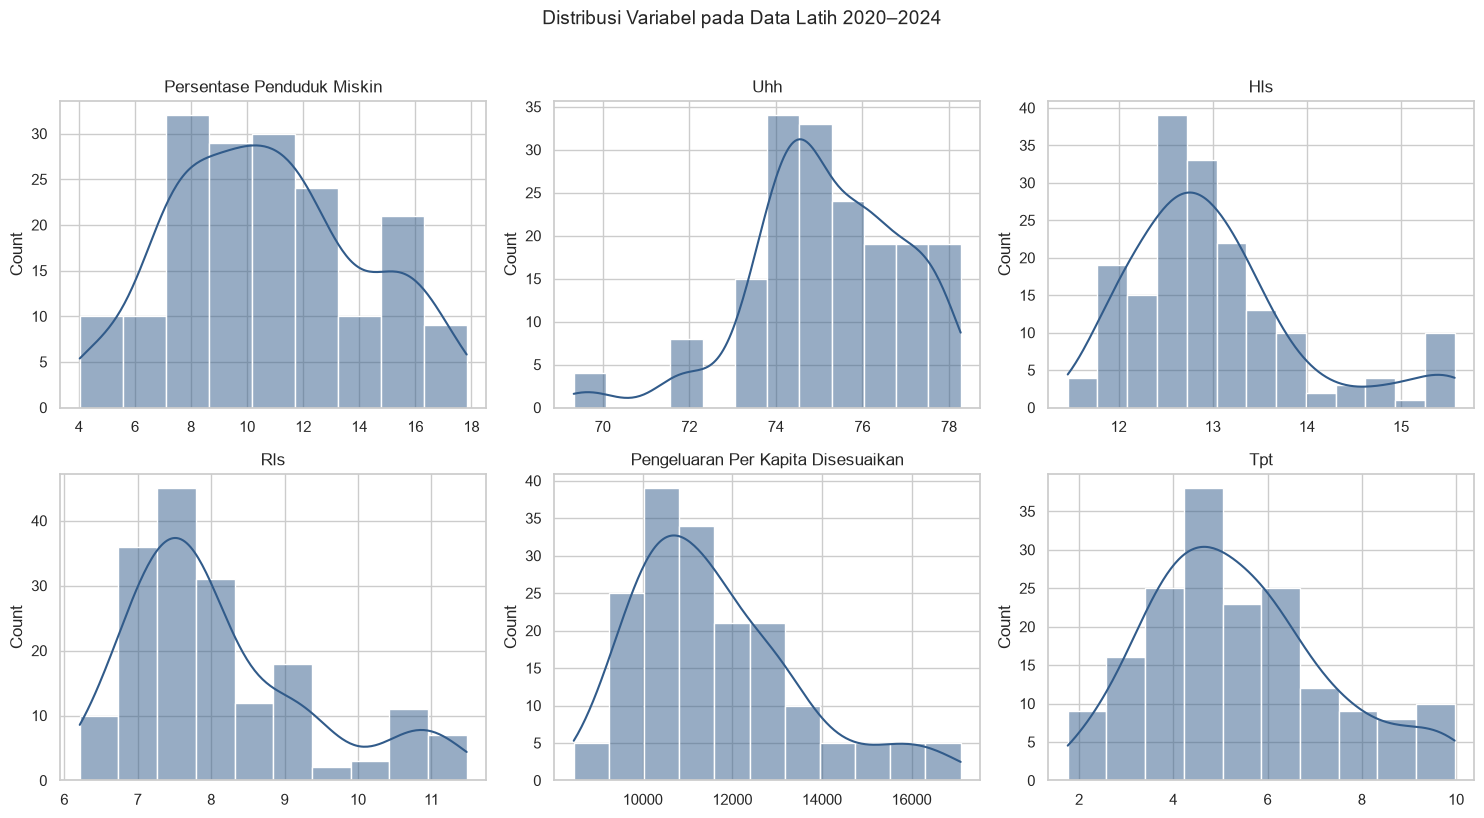

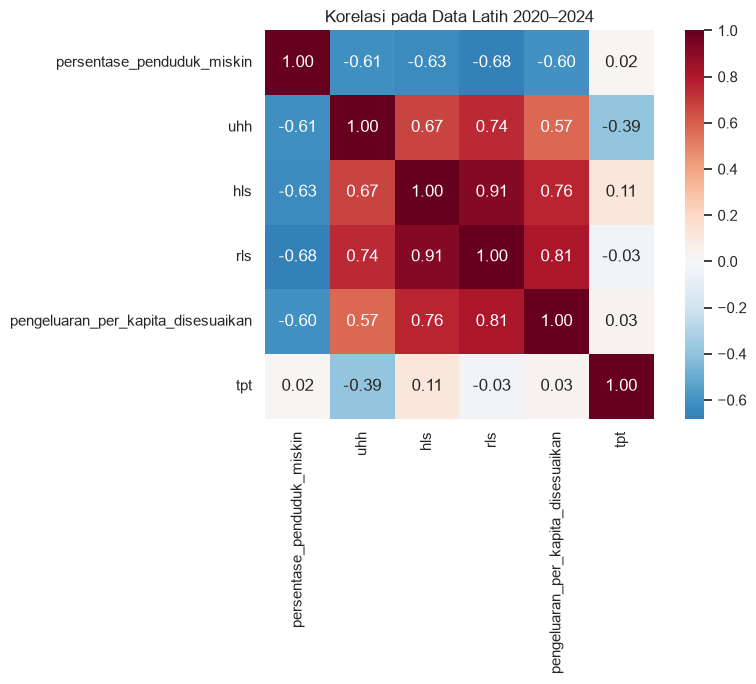

,tahun,rata_rata,median,minimum,maksimum
0,2020,11.014,10.28,4.34,17.59
1,2021,11.393,10.68,4.56,17.83
2,2022,10.582,9.85,4.25,16.41
3,2023,10.397,9.81,4.23,16.34
4,2024,10.129,9.63,4.03,15.71


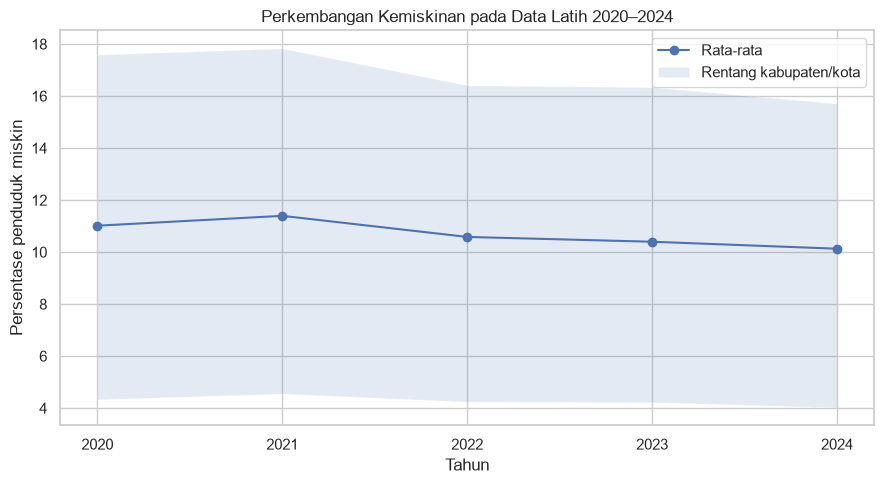

In [7]:
model_columns = [TARGET] + FEATURES
eda_train = master.loc[master["tahun"] <= 2024].copy()

print(f"Observasi EDA/data latih: {len(eda_train)}")
descriptive_statistics = eda_train[model_columns].describe().T.round(3)
display(descriptive_statistics)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for column, axis in zip(model_columns, axes.ravel()):
    sns.histplot(eda_train[column], kde=True, ax=axis, color="#315b8a")
    axis.set_title(column.replace("_", " ").title())
    axis.set_xlabel("")
plt.suptitle("Distribusi Variabel pada Data Latih 2020–2024", y=1.02, fontsize=14)
plt.tight_layout()
save_figure("01_distribusi_data_latih.png")
plt.show()

correlation = eda_train[model_columns].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(correlation, annot=True, cmap="RdBu_r", center=0, fmt=".2f", square=True)
plt.title("Korelasi pada Data Latih 2020–2024")
plt.tight_layout()
save_figure("02_korelasi_data_latih.png")
plt.show()

annual_summary = (
    eda_train.groupby("tahun")[TARGET]
    .agg(rata_rata="mean", median="median", minimum="min", maksimum="max")
    .reset_index()
)
display(annual_summary.round(3))
plt.figure(figsize=(9, 5))
plt.plot(annual_summary["tahun"], annual_summary["rata_rata"], marker="o", label="Rata-rata")
plt.fill_between(
    annual_summary["tahun"], annual_summary["minimum"], annual_summary["maksimum"],
    alpha=0.15, label="Rentang kabupaten/kota",
)
plt.title("Perkembangan Kemiskinan pada Data Latih 2020–2024")
plt.xlabel("Tahun")
plt.ylabel("Persentase penduduk miskin")
plt.xticks(EXPECTED_YEARS[:-1])
plt.legend()
plt.tight_layout()
save_figure("03_tren_kemiskinan_data_latih.png")
plt.show()


In [8]:
def calculate_vif(frame):
    rows = []
    for feature in frame.columns:
        other_features = [column for column in frame.columns if column != feature]
        auxiliary_model = LinearRegression().fit(frame[other_features], frame[feature])
        r_squared = auxiliary_model.score(frame[other_features], frame[feature])
        vif = np.inf if np.isclose(1 - r_squared, 0) else 1 / (1 - r_squared)
        rows.append({"fitur": feature, "R2_auxiliary": r_squared, "VIF": vif})
    return pd.DataFrame(rows).sort_values("VIF", ascending=False).reset_index(drop=True)


vif_table = calculate_vif(eda_train[FEATURES])
display(vif_table.round(3))
print("VIF di atas 5 perlu ditelaah, bukan otomatis menjadi alasan menghapus fitur.")


,fitur,R2_auxiliary,VIF
0,rls,0.887,8.848
1,hls,0.860,7.124
2,uhh,0.703,3.369
3,pengeluaran_per_kapita_disesuaikan,0.667,2.999
4,tpt,0.424,1.736


VIF di atas 5 perlu ditelaah, bukan otomatis menjadi alasan menghapus fitur.


## 7. Pemisahan temporal

- Data latih: 2020–2024 (175 observasi)
- Data uji akhir: 2025 (35 observasi)

Tidak digunakan pembagian acak karena observasi mempunyai dimensi waktu.


In [9]:
model_data = master.sort_values(["tahun", "kode_wilayah"]).reset_index(drop=True)
train_df = model_data.loc[model_data["tahun"] <= 2024].reset_index(drop=True)
test_df = model_data.loc[model_data["tahun"] == 2025].reset_index(drop=True)

X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_test = test_df[FEATURES]
y_test = test_df[TARGET]

assert len(train_df) == 175
assert len(test_df) == 35
assert set(train_df["tahun"].unique()) == {2020, 2021, 2022, 2023, 2024}
assert set(test_df["tahun"].unique()) == {2025}

print("Data latih:", X_train.shape, "| Data uji:", X_test.shape)


Data latih: (175, 5) | Data uji: (35, 5)


## 8. Baseline, Multiple Linear Regression, dan Random Forest

MAE menjadi metrik utama karena satuannya langsung berupa poin persentase kemiskinan. RMSE dan R² digunakan sebagai metrik pendukung. Ketidakpastian MAE dinilai dengan 2.000 bootstrap atas wilayah uji, termasuk perbandingan MAE berpasangan antarmodel.

Random Forest dituning memakai validasi expanding-year:

- latih 2020 → validasi 2021
- latih 2020–2021 → validasi 2022
- latih 2020–2022 → validasi 2023
- latih 2020–2023 → validasi 2024


In [10]:
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)

mlr = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]
)
mlr.fit(X_train, y_train)

train_year_array = train_df["tahun"].to_numpy()
expanding_year_splits = []
for validation_year in [2021, 2022, 2023, 2024]:
    train_indices = np.where(train_year_array < validation_year)[0]
    validation_indices = np.where(train_year_array == validation_year)[0]
    expanding_year_splits.append((train_indices, validation_indices))

rf_parameter_space = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 4, 6, 10, 15],
    "max_features": ["sqrt", 0.6, 1.0],
    "min_samples_split": [2, 4, 8],
    "min_samples_leaf": [1, 2, 4],
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1),
    param_distributions=rf_parameter_space,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=expanding_year_splits,
    random_state=RANDOM_STATE,
    n_jobs=1,
    refit=True,
    return_train_score=True,
)
rf_search.fit(X_train, y_train)
rf_best = rf_search.best_estimator_
rf_validation_results = (
    pd.DataFrame(rf_search.cv_results_)
    .assign(
        mean_validation_mae=lambda frame: -frame["mean_test_score"],
        std_validation_mae=lambda frame: frame["std_test_score"],
    )
    .sort_values("rank_test_score")
    [["rank_test_score", "mean_validation_mae", "std_validation_mae", "params"]]
    .reset_index(drop=True)
)

print("Parameter Random Forest terbaik:")
display(pd.Series(rf_search.best_params_, name="nilai").to_frame())
print(f"MAE validasi temporal rata-rata terbaik: {-rf_search.best_score_:.4f}")


Parameter Random Forest terbaik:


,nilai
n_estimators,300.0
min_samples_split,2.0
min_samples_leaf,1.0
max_features,0.6
max_depth,15.0


MAE validasi temporal rata-rata terbaik: 1.1836


,Model,MAE,RMSE,R2,MAE_CI95_low,MAE_CI95_high
0,Random Forest,1.0990,1.4424,0.731,0.8020,1.4193
1,Multiple Linear Regression,1.7314,2.1579,0.398,1.3157,2.1823
2,Dummy Baseline,2.6436,3.1672,-0.297,2.0427,3.2595


,perbandingan,selisih_mae,ci95_low,ci95_high
0,MLR dikurangi Random Forest,0.6336,0.2667,0.9654
1,Dummy dikurangi Random Forest,1.5397,0.9914,2.1247


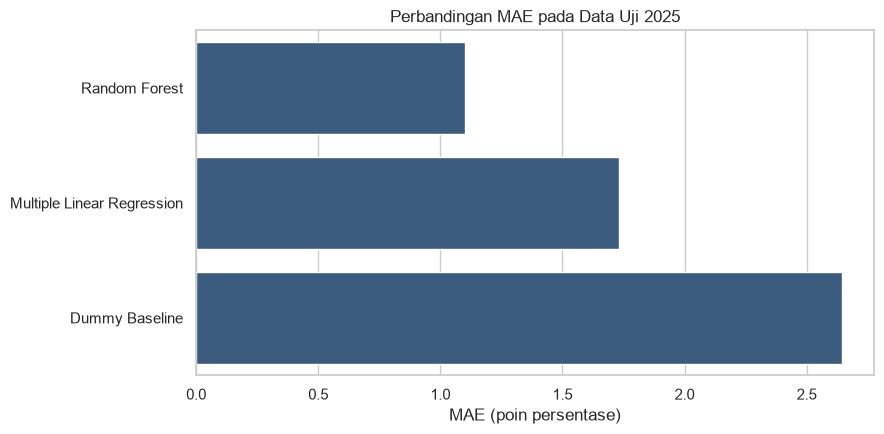

In [11]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }


def bootstrap_mae_ci(y_true, y_pred, n_bootstrap=2000, confidence=0.95):
    absolute_errors = np.abs(np.asarray(y_true) - np.asarray(y_pred))
    rng = np.random.default_rng(RANDOM_STATE)
    sample_indices = rng.integers(0, len(absolute_errors), size=(n_bootstrap, len(absolute_errors)))
    bootstrap_mae = absolute_errors[sample_indices].mean(axis=1)
    alpha = (1 - confidence) / 2
    return np.quantile(bootstrap_mae, [alpha, 1 - alpha])


def bootstrap_mae_difference(y_true, prediction_a, prediction_b, n_bootstrap=2000):
    errors_a = np.abs(np.asarray(y_true) - np.asarray(prediction_a))
    errors_b = np.abs(np.asarray(y_true) - np.asarray(prediction_b))
    rng = np.random.default_rng(RANDOM_STATE)
    sample_indices = rng.integers(0, len(errors_a), size=(n_bootstrap, len(errors_a)))
    differences = (errors_a[sample_indices] - errors_b[sample_indices]).mean(axis=1)
    return differences.mean(), *np.quantile(differences, [0.025, 0.975])


fitted_models = {
    "Dummy Baseline": dummy,
    "Multiple Linear Regression": mlr,
    "Random Forest": rf_best,
}

test_predictions = {}
comparison_rows = []
for model_name, model in fitted_models.items():
    prediction = model.predict(X_test)
    test_predictions[model_name] = prediction
    mae_ci_low, mae_ci_high = bootstrap_mae_ci(y_test, prediction)
    comparison_rows.append({
        "Model": model_name,
        **regression_metrics(y_test, prediction),
        "MAE_CI95_low": mae_ci_low,
        "MAE_CI95_high": mae_ci_high,
    })

model_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values("MAE")
    .reset_index(drop=True)
)
display(model_comparison.round(4))

paired_rows = []
for comparison_name, model_a, model_b in [
    ("MLR dikurangi Random Forest", "Multiple Linear Regression", "Random Forest"),
    ("Dummy dikurangi Random Forest", "Dummy Baseline", "Random Forest"),
]:
    mean_difference, ci_low, ci_high = bootstrap_mae_difference(
        y_test, test_predictions[model_a], test_predictions[model_b]
    )
    paired_rows.append({
        "perbandingan": comparison_name,
        "selisih_mae": mean_difference,
        "ci95_low": ci_low,
        "ci95_high": ci_high,
    })
paired_model_comparison = pd.DataFrame(paired_rows)
display(paired_model_comparison.round(4))

plt.figure(figsize=(9, 4.5))
sns.barplot(data=model_comparison, x="MAE", y="Model", color="#315b8a")
plt.title("Perbandingan MAE pada Data Uji 2025")
plt.xlabel("MAE (poin persentase)")
plt.ylabel("")
plt.tight_layout()
save_figure("04_perbandingan_mae_model.png")
plt.show()


## 9. Prediksi per kabupaten/kota dan residual


,kode_wilayah,kabupaten_kota,tahun,persentase_penduduk_miskin,prediksi_dummy,prediksi_mlr,prediksi_random_forest,residual_mlr,residual_random_forest,absolute_error_mlr,absolute_error_random_forest
27,3328,Kabupaten Tegal,2025,6.16,10.703,11.297,9.668,-5.137,-3.508,5.137,3.508
24,3325,Kabupaten Batang,2025,7.79,10.703,11.274,11.211,-3.484,-3.421,3.484,3.421
21,3322,Kabupaten Semarang,2025,6.30,10.703,9.614,8.839,-3.314,-2.539,3.314,2.539
25,3326,Kabupaten Pekalongan,2025,8.05,10.703,11.963,10.569,-3.913,-2.519,3.913,2.519
22,3323,Kabupaten Temanggung,2025,7.78,10.703,11.345,10.044,-3.565,-2.264,3.565,2.264
2,3303,Kabupaten Purbalingga,2025,12.55,10.703,11.744,14.636,0.806,-2.086,0.806,2.086
18,3319,Kabupaten Kudus,2025,6.59,10.703,8.329,8.639,-1.739,-2.049,1.739,2.049
29,3371,Kota Magelang,2025,5.68,10.703,5.695,7.425,-0.015,-1.745,0.015,1.745
6,3307,Kabupaten Wonosobo,2025,13.34,10.703,12.121,15.004,1.219,-1.664,1.219,1.664
19,3320,Kabupaten Jepara,2025,5.79,10.703,9.970,7.360,-4.180,-1.570,4.180,1.570


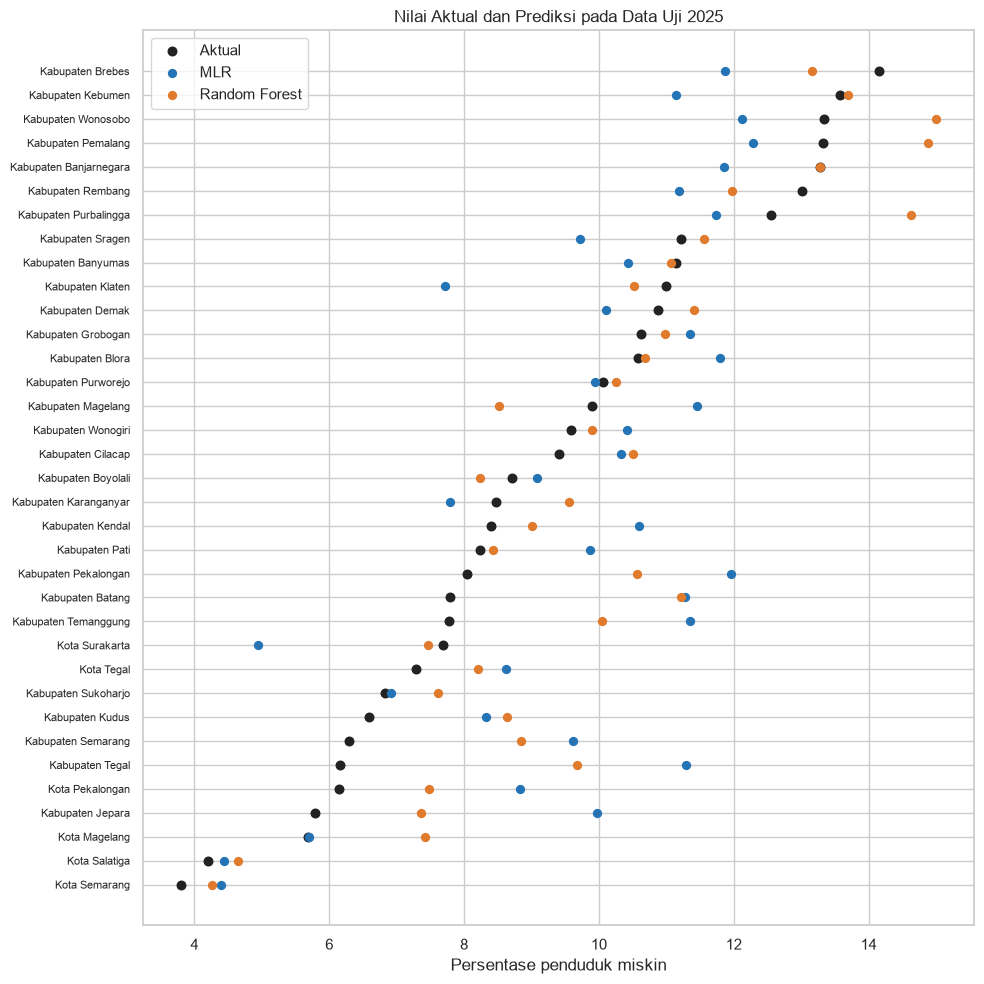

In [12]:
prediction_test = test_df[["kode_wilayah", "kabupaten_kota", "tahun", TARGET]].copy()
prediction_test["prediksi_dummy"] = test_predictions["Dummy Baseline"]
prediction_test["prediksi_mlr"] = test_predictions["Multiple Linear Regression"]
prediction_test["prediksi_random_forest"] = test_predictions["Random Forest"]
prediction_test["residual_mlr"] = prediction_test[TARGET] - prediction_test["prediksi_mlr"]
prediction_test["residual_random_forest"] = (
    prediction_test[TARGET] - prediction_test["prediksi_random_forest"]
)
prediction_test["absolute_error_mlr"] = prediction_test["residual_mlr"].abs()
prediction_test["absolute_error_random_forest"] = prediction_test[
    "residual_random_forest"
].abs()

display(
    prediction_test.sort_values("absolute_error_random_forest", ascending=False)
    .head(10)
    .round(3)
)

plot_data = prediction_test.sort_values(TARGET).reset_index(drop=True)
y_position = np.arange(len(plot_data))
plt.figure(figsize=(10, 10))
plt.scatter(plot_data[TARGET], y_position, label="Aktual", s=38, color="#222222")
plt.scatter(plot_data["prediksi_mlr"], y_position, label="MLR", s=32, color="#2474b5")
plt.scatter(
    plot_data["prediksi_random_forest"],
    y_position,
    label="Random Forest",
    s=32,
    color="#e07a2d",
)
plt.yticks(y_position, plot_data["kabupaten_kota"], fontsize=8)
plt.xlabel("Persentase penduduk miskin")
plt.ylabel("")
plt.title("Nilai Aktual dan Prediksi pada Data Uji 2025")
plt.legend()
plt.tight_layout()
save_figure("05_aktual_vs_prediksi_2025.png")
plt.show()


## 10. Interpretasi kontribusi prediktif

- MLR: koefisien prediktor yang telah distandardisasi.
- Random Forest: permutation importance pada data uji 2025.

Besaran berikut tidak boleh ditafsirkan sebagai efek kausal.


,fitur,koefisien_terstandar
0,uhh,-1.1932
1,rls,-1.1575
2,pengeluaran_per_kapita_disesuaikan,-0.5267
3,tpt,-0.4475
4,hls,0.1857


,fitur,importance_mean,importance_std
0,rls,1.2692,0.1809
1,hls,0.8931,0.1413
2,pengeluaran_per_kapita_disesuaikan,0.1388,0.0472
3,tpt,0.1055,0.0319
4,uhh,0.0549,0.0611


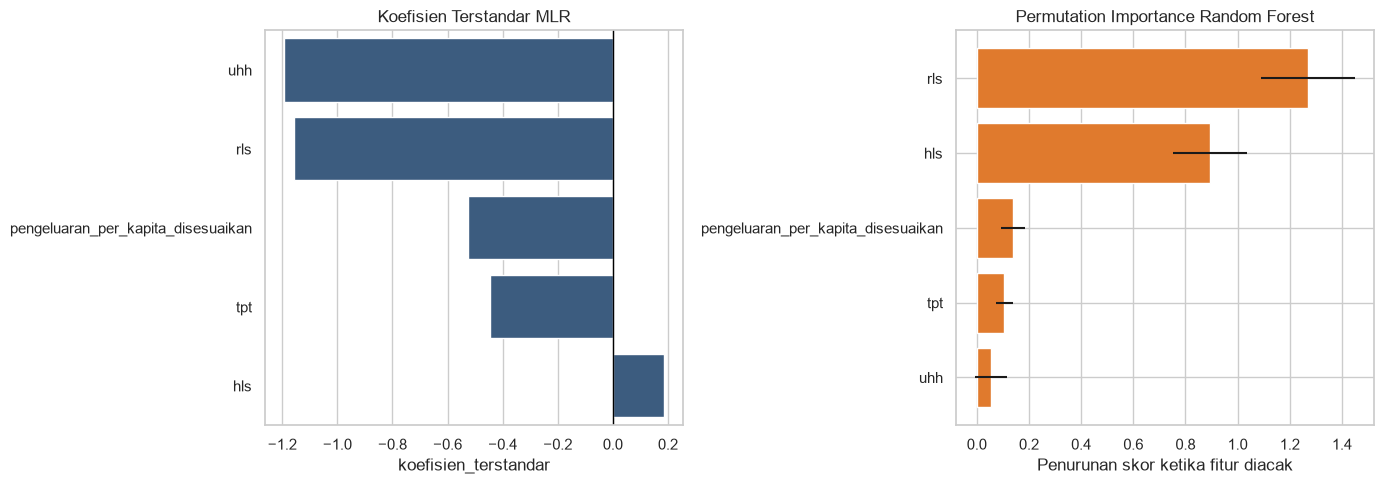

In [13]:
standardized_coefficients = (
    pd.DataFrame(
        {
            "fitur": FEATURES,
            "koefisien_terstandar": mlr.named_steps["model"].coef_,
        }
    )
    .assign(absolut=lambda frame: frame["koefisien_terstandar"].abs())
    .sort_values("absolut", ascending=False)
    .reset_index(drop=True)
)

rf_permutation = permutation_importance(
    rf_best,
    X_test,
    y_test,
    scoring="neg_mean_absolute_error",
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=1,
)
permutation_table = (
    pd.DataFrame(
        {
            "fitur": FEATURES,
            "importance_mean": rf_permutation.importances_mean,
            "importance_std": rf_permutation.importances_std,
        }
    )
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

display(standardized_coefficients.drop(columns="absolut").round(4))
display(permutation_table.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(
    data=standardized_coefficients,
    x="koefisien_terstandar",
    y="fitur",
    color="#315b8a",
    ax=axes[0],
)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Koefisien Terstandar MLR")
axes[0].set_ylabel("")

axes[1].barh(
    permutation_table["fitur"],
    permutation_table["importance_mean"],
    xerr=permutation_table["importance_std"],
    color="#e07a2d",
)
axes[1].invert_yaxis()
axes[1].set_title("Permutation Importance Random Forest")
axes[1].set_xlabel("Penurunan skor ketika fitur diacak")
axes[1].set_ylabel("")
plt.tight_layout()
save_figure("06_interpretasi_fitur.png")
plt.show()


## 11. Diagnostik residual Multiple Linear Regression

Diagnostik dilakukan pada residual data latih. Uji Shapiro–Wilk menilai normalitas residual dan Breusch–Pagan menilai heteroskedastisitas. Koefisien inferensial juga dilaporkan dengan standard error yang dikelompokkan menurut kabupaten/kota untuk mengakomodasi pengukuran berulang. Hasil uji bersifat pendukung; keputusan utama penelitian tetap berdasarkan performa prediksi pada data uji 2025.


,uji,statistik,p_value
0,Shapiro-Wilk,0.9830,0.0311
1,Breusch-Pagan LM,15.3190,0.0091
2,Breusch-Pagan F,3.2426,0.0080


,term,koefisien,standard_error_cluster,t_statistic,p_value,ci95_low,ci95_high
0,const,71.5526,24.0474,2.9755,0.0054,22.6824,120.4227
1,uhh,-0.6850,0.3855,-1.7767,0.0846,-1.4685,0.0985
2,hls,0.2026,1.1925,0.1699,0.8661,-2.2209,2.6261
3,rls,-0.9097,0.6844,-1.3291,0.1927,-2.3006,0.4813
4,pengeluaran_per_kapita_disesuaikan,-0.0003,0.0003,-0.8838,0.3830,-0.0009,0.0004
5,tpt,-0.2351,0.2135,-1.1012,0.2786,-0.6691,0.1988


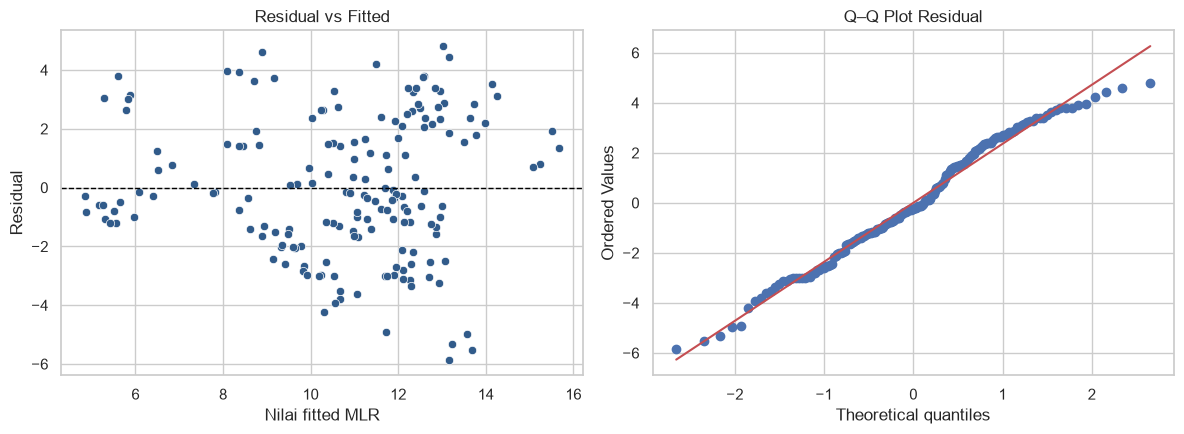

In [14]:
train_fitted_mlr = mlr.predict(X_train)
train_residual_mlr = y_train.to_numpy() - train_fitted_mlr

shapiro_statistic, shapiro_pvalue = stats.shapiro(train_residual_mlr)
X_train_ols = sm.add_constant(X_train.astype(float))
ols_model = sm.OLS(y_train.to_numpy(), X_train_ols).fit()
bp_statistic, bp_pvalue, bp_f_statistic, bp_f_pvalue = het_breuschpagan(
    ols_model.resid, ols_model.model.exog
)
ols_clustered = ols_model.get_robustcov_results(
    cov_type="cluster", groups=train_df["kode_wilayah"]
)
clustered_ci = ols_clustered.conf_int(alpha=0.05)
clustered_coefficient_table = pd.DataFrame({
    "term": X_train_ols.columns,
    "koefisien": ols_clustered.params,
    "standard_error_cluster": ols_clustered.bse,
    "t_statistic": ols_clustered.tvalues,
    "p_value": ols_clustered.pvalues,
    "ci95_low": clustered_ci[:, 0],
    "ci95_high": clustered_ci[:, 1],
})
diagnostic_tests = pd.DataFrame([
    {"uji": "Shapiro-Wilk", "statistik": shapiro_statistic, "p_value": shapiro_pvalue},
    {"uji": "Breusch-Pagan LM", "statistik": bp_statistic, "p_value": bp_pvalue},
    {"uji": "Breusch-Pagan F", "statistik": bp_f_statistic, "p_value": bp_f_pvalue},
])
display(diagnostic_tests.round(4))
display(clustered_coefficient_table.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.scatterplot(x=train_fitted_mlr, y=train_residual_mlr, ax=axes[0], color="#315b8a")
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_xlabel("Nilai fitted MLR")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residual vs Fitted")

stats.probplot(train_residual_mlr, dist="norm", plot=axes[1])
axes[1].set_title("Q–Q Plot Residual")
plt.tight_layout()
save_figure("07_diagnostik_residual_mlr.png")
plt.show()


## 12. Analisis sensitivitas

Sesuai rancangan proposal, model utama dibandingkan dengan:

1. Model tanpa HLS, untuk menelaah korelasi tinggi HLS–RLS.
2. Model tanpa pengeluaran per kapita yang disesuaikan, untuk menelaah kedekatan konseptualnya dengan kemiskinan.

Random Forest pada setiap varian menggunakan parameter terbaik hasil tuning model utama, kemudian dilatih ulang pada fitur varian tersebut.


,Varian,Model,Jumlah fitur,MAE,RMSE,R2
0,Model utama,Multiple Linear Regression,5,1.7314,2.1579,0.3980
1,Model utama,Random Forest,5,1.0990,1.4424,0.7310
2,Tanpa HLS,Multiple Linear Regression,4,1.7383,2.1628,0.3952
3,Tanpa HLS,Random Forest,4,1.4005,1.7450,0.6063
4,Tanpa pengeluaran per kapita,Multiple Linear Regression,4,1.7984,2.2560,0.3420
5,Tanpa pengeluaran per kapita,Random Forest,4,1.0572,1.3343,0.7698


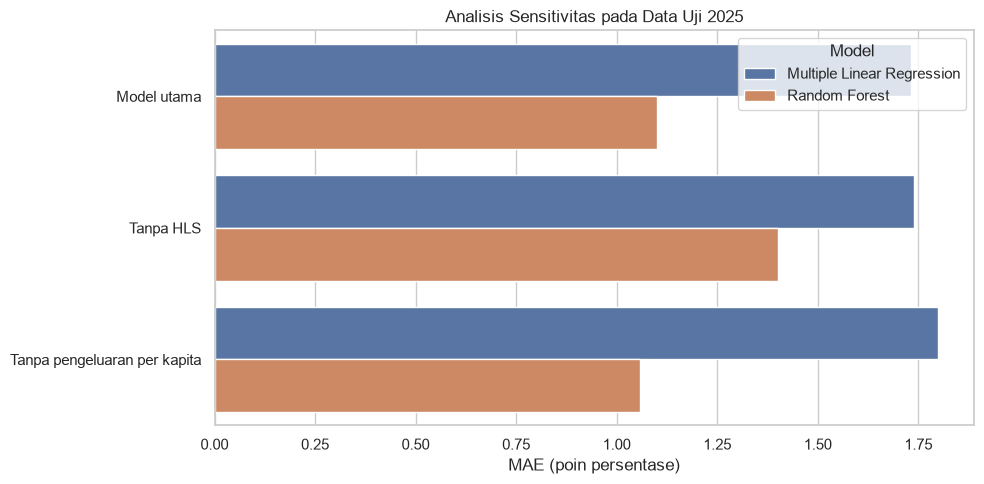

In [15]:
sensitivity_variants = {
    "Model utama": FEATURES,
    "Tanpa HLS": [feature for feature in FEATURES if feature != "hls"],
    "Tanpa pengeluaran per kapita": [
        feature
        for feature in FEATURES
        if feature != "pengeluaran_per_kapita_disesuaikan"
    ],
}

sensitivity_rows = []
for variant_name, variant_features in sensitivity_variants.items():
    mlr_variant = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("model", LinearRegression()),
        ]
    )
    rf_variant = clone(rf_best)

    for model_name, model in {
        "Multiple Linear Regression": mlr_variant,
        "Random Forest": rf_variant,
    }.items():
        model.fit(train_df[variant_features], y_train)
        prediction = model.predict(test_df[variant_features])
        sensitivity_rows.append(
            {
                "Varian": variant_name,
                "Model": model_name,
                "Jumlah fitur": len(variant_features),
                **regression_metrics(y_test, prediction),
            }
        )

sensitivity_results = pd.DataFrame(sensitivity_rows)
display(sensitivity_results.round(4))

plt.figure(figsize=(10, 5))
sns.barplot(data=sensitivity_results, x="MAE", y="Varian", hue="Model")
plt.title("Analisis Sensitivitas pada Data Uji 2025")
plt.xlabel("MAE (poin persentase)")
plt.ylabel("")
plt.tight_layout()
save_figure("08_analisis_sensitivitas.png")
plt.show()


## 13. Menyimpan seluruh hasil

File CSV di bawah dapat digunakan untuk penulisan Bab IV. Jangan mengubah file mentah; lakukan perbaikan melalui kode lalu jalankan ulang notebook.


In [16]:
output_files = {
    "dataset_gabungan": MASTER_PATH,
    "perbandingan_model": OUTPUT_DIR / "hasil_perbandingan_model.csv",
    "perbandingan_mae_berpasangan": OUTPUT_DIR / "perbandingan_mae_berpasangan.csv",
    "validasi_temporal_rf": OUTPUT_DIR / "validasi_temporal_random_forest.csv",
    "prediksi_2025": OUTPUT_DIR / "prediksi_kemiskinan_2025.csv",
    "koefisien_mlr": OUTPUT_DIR / "koefisien_terstandar_mlr.csv",
    "koefisien_mlr_cluster_robust": OUTPUT_DIR / "koefisien_mlr_cluster_robust.csv",
    "diagnostik_mlr": OUTPUT_DIR / "diagnostik_mlr.csv",
    "statistik_deskriptif": OUTPUT_DIR / "statistik_deskriptif_data_latih.csv",
    "ringkasan_tahunan": OUTPUT_DIR / "ringkasan_kemiskinan_tahunan.csv",
    "vif": OUTPUT_DIR / "vif_prediktor.csv",
    "permutation_importance_rf": OUTPUT_DIR / "permutation_importance_random_forest.csv",
    "analisis_sensitivitas": OUTPUT_DIR / "hasil_analisis_sensitivitas.csv",
    "audit_sumber": OUTPUT_DIR / "audit_sumber_data.csv",
}

model_comparison.to_csv(output_files["perbandingan_model"], index=False, encoding="utf-8-sig")
paired_model_comparison.to_csv(
    output_files["perbandingan_mae_berpasangan"], index=False, encoding="utf-8-sig"
)
rf_validation_results.to_csv(
    output_files["validasi_temporal_rf"], index=False, encoding="utf-8-sig"
)
prediction_test.to_csv(output_files["prediksi_2025"], index=False, encoding="utf-8-sig")
standardized_coefficients.drop(columns="absolut").to_csv(
    output_files["koefisien_mlr"], index=False, encoding="utf-8-sig"
)
clustered_coefficient_table.to_csv(
    output_files["koefisien_mlr_cluster_robust"], index=False, encoding="utf-8-sig"
)
diagnostic_tests.to_csv(output_files["diagnostik_mlr"], index=False, encoding="utf-8-sig")
descriptive_statistics.to_csv(output_files["statistik_deskriptif"], encoding="utf-8-sig")
annual_summary.to_csv(output_files["ringkasan_tahunan"], index=False, encoding="utf-8-sig")
vif_table.to_csv(output_files["vif"], index=False, encoding="utf-8-sig")
permutation_table.to_csv(
    output_files["permutation_importance_rf"], index=False, encoding="utf-8-sig"
)
sensitivity_results.to_csv(
    output_files["analisis_sensitivitas"], index=False, encoding="utf-8-sig"
)
source_audit.to_csv(output_files["audit_sumber"], index=False, encoding="utf-8-sig")

print("File hasil:")
for label, path in output_files.items():
    print(f"- {label}: {display_path(path)}")

DOWNLOAD_MASTER_DATASET = False
if DOWNLOAD_MASTER_DATASET and IN_COLAB:
    from google.colab import files
    files.download(str(MASTER_PATH))


File hasil:
- dataset_gabungan: data\processed\kemiskinan_jateng_2020_2025.csv
- perbandingan_model: reports\hasil_perbandingan_model.csv
- perbandingan_mae_berpasangan: reports\perbandingan_mae_berpasangan.csv
- validasi_temporal_rf: reports\validasi_temporal_random_forest.csv
- prediksi_2025: reports\prediksi_kemiskinan_2025.csv
- koefisien_mlr: reports\koefisien_terstandar_mlr.csv
- koefisien_mlr_cluster_robust: reports\koefisien_mlr_cluster_robust.csv
- diagnostik_mlr: reports\diagnostik_mlr.csv
- statistik_deskriptif: reports\statistik_deskriptif_data_latih.csv
- ringkasan_tahunan: reports\ringkasan_kemiskinan_tahunan.csv
- vif: reports\vif_prediktor.csv
- permutation_importance_rf: reports\permutation_importance_random_forest.csv
- analisis_sensitivitas: reports\hasil_analisis_sensitivitas.csv
- audit_sumber: reports\audit_sumber_data.csv


In [17]:
missing_outputs = [str(path) for path in output_files.values() if not path.exists()]
assert not missing_outputs, f"Artefak belum terbentuk: {missing_outputs}"
print(f"Validasi selesai: {len(output_files)} artefak tabel dan {len(list(FIGURES_DIR.glob('*.png')))} figur tersedia.")

Validasi selesai: 14 artefak tabel dan 8 figur tersedia.


## Catatan pelaporan skripsi

- Laporkan bahwa data akhir memiliki 210 observasi tanpa missing value dan duplikasi.
- Nyatakan secara eksplisit bahwa 2025 tidak digunakan untuk EDA, penentuan model, maupun tuning, melainkan sebagai data uji akhir yang dikunci.
- Bandingkan setiap model dengan Dummy Baseline, bukan hanya MLR melawan Random Forest.
- Utamakan MAE; gunakan RMSE dan R² sebagai pendukung.
- Jelaskan tanda dan besar koefisien MLR serta permutation importance sebagai kontribusi prediktif, bukan sebab-akibat.
- Laporkan interval kepercayaan bootstrap MAE dan diagnostik MLR sebagai ukuran ketidakpastian serta pemeriksaan asumsi.
- Untuk inferensi koefisien MLR, gunakan standard error cluster-robust menurut kabupaten/kota dan hindari klaim kausal.
- Bahas hasil model sensitivitas ketika HLS atau pengeluaran per kapita dikeluarkan.
